# 🏎️ Semana 6 — Modelos Avanzados
**Módulos 13 y 14 del curso — Árboles, Ensembles y Boosting**

Superamos el baseline lineal con modelos no lineales basados en árboles de decisión.

### Objetivos
1. Entrenar **Random Forest** (regresión y clasificación)
2. Entrenar **XGBoost** como modelo de boosting
3. Optimizar hiperparámetros con `RandomizedSearchCV`
4. Comparar feature importance: Gini (RF) vs Gain (XGB)
5. Comparación sistemática contra el baseline de la semana 5
6. Elegir el mejor modelo para tuning fino en la semana 7

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection   import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing     import StandardScaler
from sklearn.ensemble          import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics           import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay, confusion_matrix
)
from xgboost import XGBRegressor, XGBClassifier
from scipy.stats import randint, uniform

plt.style.use('ggplot')
sns.set_palette('Set2')
BLUE = '#4C72B0'; ORANGE = '#DD8452'; GREEN = '#55A868'; RED = '#C44E52'

df = pd.read_csv('../data/f1_master_clean.csv')
baseline = pd.read_csv('../data/metricas_modelos.csv')

print(f'Dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
print('\nBaseline de referencia (Semana 5):')
print(baseline.to_string(index=False))

Dataset: 3547 filas × 36 columnas

Baseline de referencia (Semana 5):
        Tarea                Modelo   MAE  RMSE    R²   AUC Accuracy
    Regresión         Dummy (media) 4.054 4.797  -0.0     —        —
    Regresión      Regresión Lineal 2.541 3.244 0.542     —        —
Clasificación Dummy (estratificado)     —     —     — 0.466    0.556
Clasificación   Regresión Logística     —     —     — 0.881    0.778
    Regresión         Random Forest 2.275 2.957  0.62     —        —
    Regresión               XGBoost 2.238 2.933 0.626     —        —
Clasificación         Random Forest     —     —     — 0.903    0.817
Clasificación               XGBoost     —     —     — 0.905    0.811


In [2]:
# Mismo pipeline de preparación que la semana 5
FEATURES = ['grid', 'team_rank', 'num_stops', 'total_pit_time', 'driver_age']
TARGET_REG = 'position'
TARGET_CLF = 'top3'

cols_needed = FEATURES + [TARGET_REG, TARGET_CLF]
df_model = df[cols_needed].dropna().copy()

X = df_model[FEATURES]
y_reg = df_model[TARGET_REG]
y_clf = df_model[TARGET_CLF]

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Los árboles no requieren scaling, pero lo mantenemos para comparabilidad
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURES)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=FEATURES)

print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')

Train: 720  |  Test: 180


---
## Parte 1 — Random Forest

Un ensemble de árboles de decisión entrenados con **bagging** y selección aleatoria de features.
Robusto a outliers y no requiere normalización (aunque la usamos por consistencia).

### ¿Por qué Random Forest?
- Captura relaciones no lineales que la regresión lineal no puede
- Da importancia de features basada en reducción de impureza (Gini)
- Menos propenso a overfitting que un árbol individual

In [3]:
# --- 1a. Random Forest Regressor (predecir position) ---
param_dist_rf_reg = {
    'n_estimators':      randint(100, 500),
    'max_depth':         [None, 5, 10, 15, 20],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
    'max_features':      ['sqrt', 'log2', 0.5, 0.7]
}

rf_reg_base = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_reg_search = RandomizedSearchCV(
    rf_reg_base, param_dist_rf_reg,
    n_iter=30, cv=5, scoring='neg_mean_absolute_error',
    random_state=42, n_jobs=-1, verbose=0
)
rf_reg_search.fit(X_train_sc, y_reg_train)

rf_reg_best = rf_reg_search.best_estimator_
y_rf_reg_pred = rf_reg_best.predict(X_test_sc)

rf_mae  = mean_absolute_error(y_reg_test, y_rf_reg_pred)
rf_rmse = np.sqrt(mean_squared_error(y_reg_test, y_rf_reg_pred))
rf_r2   = r2_score(y_reg_test, y_rf_reg_pred)

print('📊 Random Forest Regressor:')
print(f'   MAE:  {rf_mae:.3f} posiciones')
print(f'   RMSE: {rf_rmse:.3f} posiciones')
print(f'   R²:   {rf_r2:.3f}')
print(f'\nMejores hiperparámetros:')
for k, v in rf_reg_search.best_params_.items():
    print(f'   {k}: {v}')

📊 Random Forest Regressor:
   MAE:  2.275 posiciones
   RMSE: 2.957 posiciones
   R²:   0.620

Mejores hiperparámetros:
   max_depth: 20
   max_features: log2
   min_samples_leaf: 4
   min_samples_split: 16
   n_estimators: 363


In [4]:
# --- 1b. Random Forest Classifier (predecir top3) ---
param_dist_rf_clf = {
    'n_estimators':      randint(100, 500),
    'max_depth':         [None, 5, 10, 15],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
    'max_features':      ['sqrt', 'log2', 0.5]
}

rf_clf_base = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
rf_clf_search = RandomizedSearchCV(
    rf_clf_base, param_dist_rf_clf,
    n_iter=30, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=0
)
rf_clf_search.fit(X_train_sc, y_clf_train)

rf_clf_best   = rf_clf_search.best_estimator_
y_rf_clf_pred = rf_clf_best.predict(X_test_sc)
y_rf_clf_prob = rf_clf_best.predict_proba(X_test_sc)[:, 1]

rf_acc = accuracy_score(y_clf_test, y_rf_clf_pred)
rf_auc = roc_auc_score(y_clf_test, y_rf_clf_prob)

print('📊 Random Forest Classifier:')
print(f'   Accuracy: {rf_acc:.3f}')
print(f'   ROC-AUC:  {rf_auc:.3f}')
print(f'\nMejores hiperparámetros:')
for k, v in rf_clf_search.best_params_.items():
    print(f'   {k}: {v}')

📊 Random Forest Classifier:
   Accuracy: 0.817
   ROC-AUC:  0.903

Mejores hiperparámetros:
   max_depth: 5
   max_features: sqrt
   min_samples_leaf: 9
   min_samples_split: 18
   n_estimators: 158


---
## Parte 2 — XGBoost

Gradient Boosting con regularización L1/L2. Construye árboles de forma **secuencial**,
donde cada árbol corrige los errores del anterior. Estado del arte en tabular data.

### ¿Por qué XGBoost?
- Captura interacciones complejas entre features
- Regularización incorporada (evita overfitting)
- Generalmente supera a Random Forest en tabular data con hiperparámetros bien tunados

In [5]:
# --- 2a. XGBoost Regressor ---
param_dist_xgb_reg = {
    'n_estimators':    randint(100, 600),
    'max_depth':       randint(3, 10),
    'learning_rate':   uniform(0.01, 0.3),
    'subsample':       uniform(0.6, 0.4),
    'colsample_bytree':uniform(0.6, 0.4),
    'reg_alpha':       uniform(0, 1),
    'reg_lambda':      uniform(0.5, 2),
    'min_child_weight':randint(1, 10)
}

xgb_reg_base = XGBRegressor(random_state=42, n_jobs=-1,
                              eval_metric='mae', verbosity=0)
xgb_reg_search = RandomizedSearchCV(
    xgb_reg_base, param_dist_xgb_reg,
    n_iter=40, cv=5, scoring='neg_mean_absolute_error',
    random_state=42, n_jobs=-1, verbose=0
)
xgb_reg_search.fit(X_train_sc, y_reg_train)

xgb_reg_best  = xgb_reg_search.best_estimator_
y_xgb_reg_pred = xgb_reg_best.predict(X_test_sc)

xgb_mae  = mean_absolute_error(y_reg_test, y_xgb_reg_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_reg_test, y_xgb_reg_pred))
xgb_r2   = r2_score(y_reg_test, y_xgb_reg_pred)

print('📊 XGBoost Regressor:')
print(f'   MAE:  {xgb_mae:.3f} posiciones')
print(f'   RMSE: {xgb_rmse:.3f} posiciones')
print(f'   R²:   {xgb_r2:.3f}')
print(f'\nMejores hiperparámetros:')
for k, v in xgb_reg_search.best_params_.items():
    print(f'   {k}: {v:.4f}' if isinstance(v, float) else f'   {k}: {v}')

📊 XGBoost Regressor:
   MAE:  2.238 posiciones
   RMSE: 2.933 posiciones
   R²:   0.626

Mejores hiperparámetros:
   colsample_bytree: 0.9531
   learning_rate: 0.0666
   max_depth: 3
   min_child_weight: 3
   n_estimators: 246
   reg_alpha: 0.7260
   reg_lambda: 2.2942
   subsample: 0.9548


In [6]:
# --- 2b. XGBoost Classifier ---
scale_pos_weight = (y_clf_train == 0).sum() / (y_clf_train == 1).sum()

param_dist_xgb_clf = {
    'n_estimators':    randint(100, 600),
    'max_depth':       randint(3, 10),
    'learning_rate':   uniform(0.01, 0.3),
    'subsample':       uniform(0.6, 0.4),
    'colsample_bytree':uniform(0.6, 0.4),
    'reg_alpha':       uniform(0, 1),
    'reg_lambda':      uniform(0.5, 2),
    'min_child_weight':randint(1, 10)
}

xgb_clf_base = XGBClassifier(
    random_state=42, n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc', verbosity=0
)
xgb_clf_search = RandomizedSearchCV(
    xgb_clf_base, param_dist_xgb_clf,
    n_iter=40, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=0
)
xgb_clf_search.fit(X_train_sc, y_clf_train)

xgb_clf_best   = xgb_clf_search.best_estimator_
y_xgb_clf_pred = xgb_clf_best.predict(X_test_sc)
y_xgb_clf_prob = xgb_clf_best.predict_proba(X_test_sc)[:, 1]

xgb_acc = accuracy_score(y_clf_test, y_xgb_clf_pred)
xgb_auc = roc_auc_score(y_clf_test, y_xgb_clf_prob)

print('📊 XGBoost Classifier:')
print(f'   Accuracy: {xgb_acc:.3f}')
print(f'   ROC-AUC:  {xgb_auc:.3f}')
print(f'\n   scale_pos_weight: {scale_pos_weight:.2f} (balance de clases)')

📊 XGBoost Classifier:
   Accuracy: 0.811
   ROC-AUC:  0.905

   scale_pos_weight: 2.26 (balance de clases)


---
## Parte 3 — Feature Importance

Comparamos la importancia de cada feature según dos criterios:
- **Random Forest:** reducción de impureza Gini (promedio entre árboles)
- **XGBoost:** gain total acumulado en todos los splits

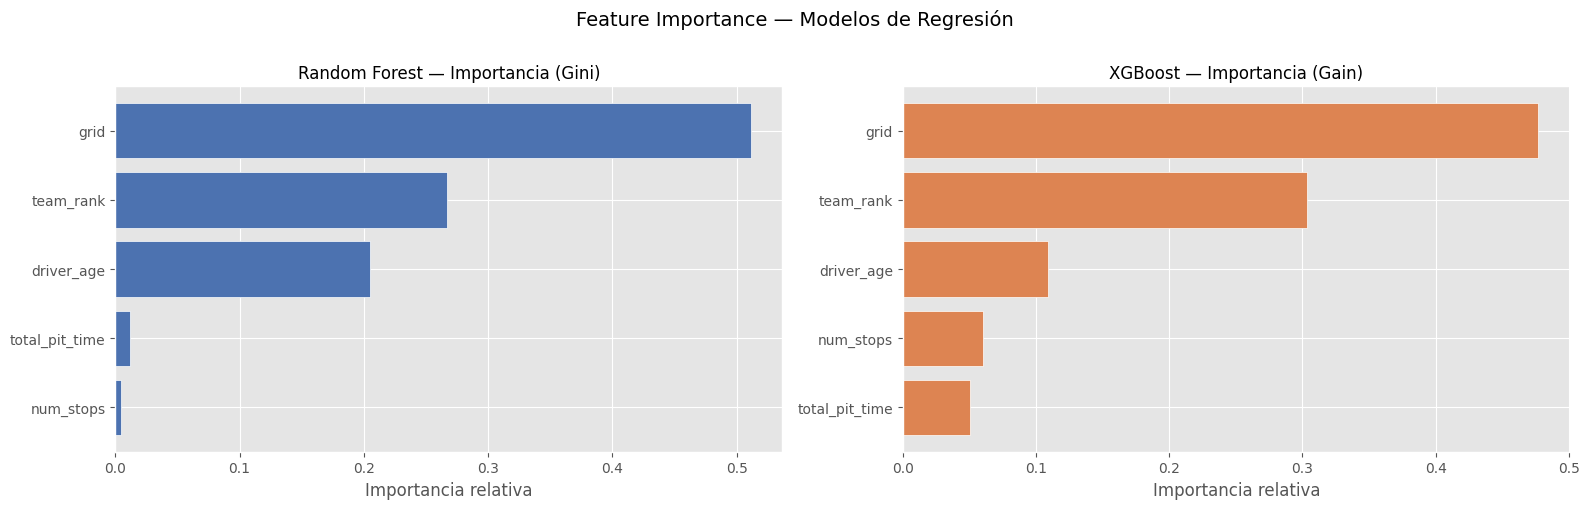


Comparación de feature importance (modelos de regresión):
                RF (Gini)  XGB (Gain)  Ranking RF  Ranking XGB
driver_age         0.2052      0.1088           3            3
grid               0.5113      0.4769           1            1
num_stops          0.0046      0.0605           5            4
team_rank          0.2671      0.3036           2            2
total_pit_time     0.0117      0.0501           4            5


In [7]:
# Feature importance — regresores
fi_rf  = pd.Series(rf_reg_best.feature_importances_,  index=FEATURES).sort_values(ascending=False)
fi_xgb = pd.Series(xgb_reg_best.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# RF
axes[0].barh(fi_rf.index[::-1], fi_rf.values[::-1], color=BLUE, edgecolor='white')
axes[0].set_title('Random Forest — Importancia (Gini)', fontsize=12)
axes[0].set_xlabel('Importancia relativa')

# XGB
axes[1].barh(fi_xgb.index[::-1], fi_xgb.values[::-1], color=ORANGE, edgecolor='white')
axes[1].set_title('XGBoost — Importancia (Gain)', fontsize=12)
axes[1].set_xlabel('Importancia relativa')

plt.suptitle('Feature Importance — Modelos de Regresión', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/06_feature_importance_reg.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla comparativa
fi_compare = pd.DataFrame({'RF (Gini)': fi_rf, 'XGB (Gain)': fi_xgb})
fi_compare['Ranking RF']  = fi_rf.rank(ascending=False).astype(int)
fi_compare['Ranking XGB'] = fi_xgb.rank(ascending=False).astype(int)
print('\nComparación de feature importance (modelos de regresión):')
print(fi_compare.round(4).to_string())

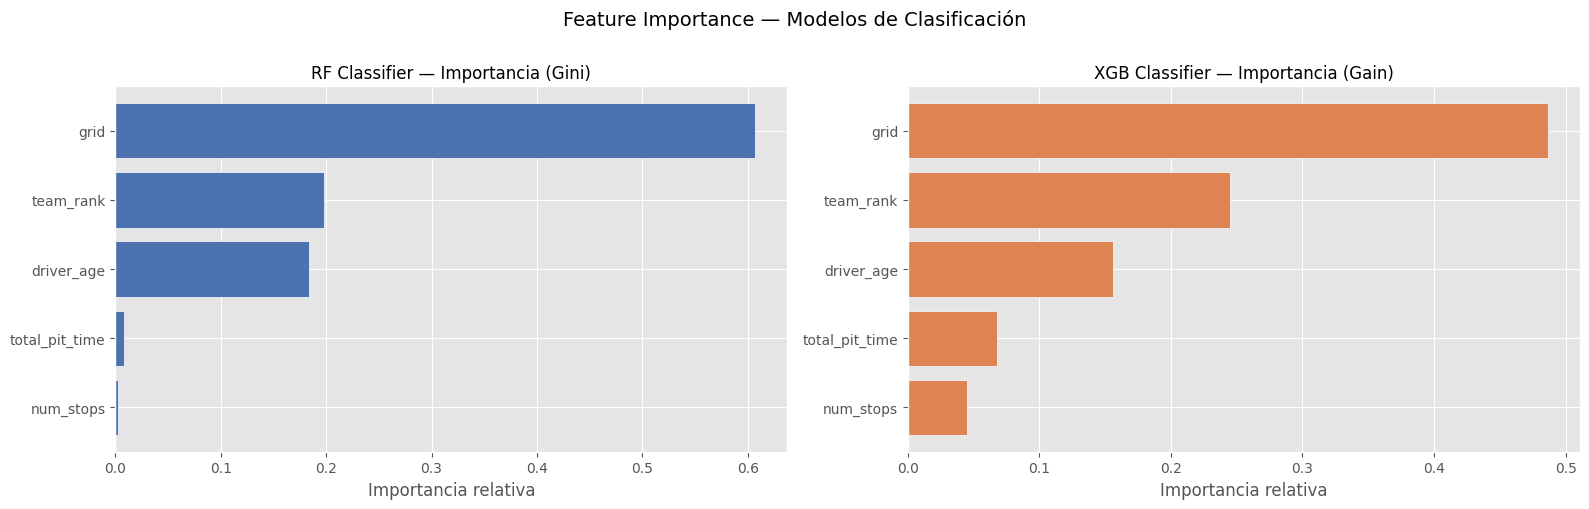

In [8]:
# Feature importance — clasificadores
fi_rf_c  = pd.Series(rf_clf_best.feature_importances_,  index=FEATURES).sort_values(ascending=False)
fi_xgb_c = pd.Series(xgb_clf_best.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].barh(fi_rf_c.index[::-1],  fi_rf_c.values[::-1],  color=BLUE,   edgecolor='white')
axes[0].set_title('RF Classifier — Importancia (Gini)', fontsize=12)
axes[0].set_xlabel('Importancia relativa')

axes[1].barh(fi_xgb_c.index[::-1], fi_xgb_c.values[::-1], color=ORANGE, edgecolor='white')
axes[1].set_title('XGB Classifier — Importancia (Gain)', fontsize=12)
axes[1].set_xlabel('Importancia relativa')

plt.suptitle('Feature Importance — Modelos de Clasificación', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/06_feature_importance_clf.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Parte 4 — Curvas ROC y diagnóstico visual

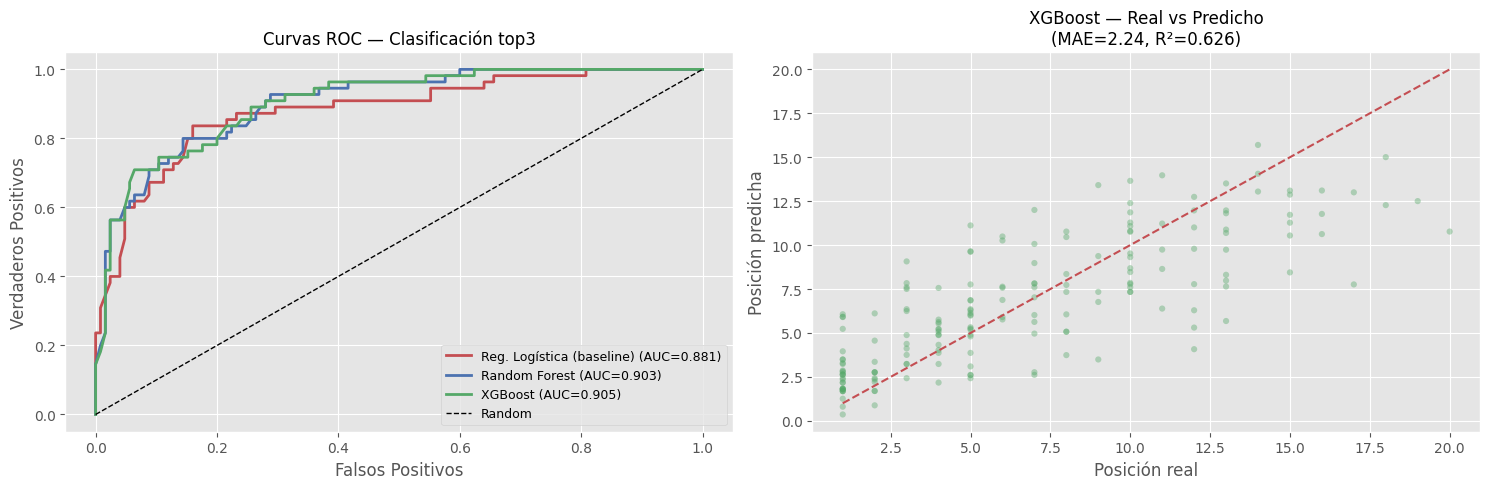

In [9]:
from sklearn.linear_model import LogisticRegression as LR

# Re-entrenar logística del baseline para la curva ROC comparativa
lr_baseline = LR(max_iter=1000, random_state=42, class_weight='balanced')
lr_baseline.fit(X_train_sc, y_clf_train)
y_lr_prob = lr_baseline.predict_proba(X_test_sc)[:, 1]
lr_auc = roc_auc_score(y_clf_test, y_lr_prob)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Curvas ROC comparativas ---
for (label, probs, auc_val, color) in [
    ('Reg. Logística (baseline)', y_lr_prob,      lr_auc,  RED),
    ('Random Forest',             y_rf_clf_prob,  rf_auc,  BLUE),
    ('XGBoost',                   y_xgb_clf_prob, xgb_auc, GREEN),
]:
    fpr, tpr, _ = roc_curve(y_clf_test, probs)
    axes[0].plot(fpr, tpr, linewidth=2, label=f'{label} (AUC={auc_val:.3f})', color=color)

axes[0].plot([0,1],[0,1], 'k--', linewidth=1, label='Random')
axes[0].set_title('Curvas ROC — Clasificación top3', fontsize=12)
axes[0].set_xlabel('Falsos Positivos')
axes[0].set_ylabel('Verdaderos Positivos')
axes[0].legend(fontsize=9)

# --- Scatter real vs predicho (mejor regresor) ---
mejor_pred = y_xgb_reg_pred if xgb_mae < rf_mae else y_rf_reg_pred
mejor_mae  = min(xgb_mae, rf_mae)
mejor_r2   = xgb_r2 if xgb_mae < rf_mae else rf_r2
mejor_name = 'XGBoost' if xgb_mae < rf_mae else 'Random Forest'

axes[1].scatter(y_reg_test, mejor_pred, alpha=0.4, color=GREEN, s=20, edgecolors='none')
lim = max(y_reg_test.max(), mejor_pred.max())
axes[1].plot([1,lim],[1,lim], color=RED, linestyle='--', linewidth=1.5)
axes[1].set_title(f'{mejor_name} — Real vs Predicho\n(MAE={mejor_mae:.2f}, R²={mejor_r2:.3f})', fontsize=12)
axes[1].set_xlabel('Posición real')
axes[1].set_ylabel('Posición predicha')

plt.tight_layout()
plt.savefig('../figures/06_roc_y_prediccion.png', dpi=150, bbox_inches='tight')
plt.show()

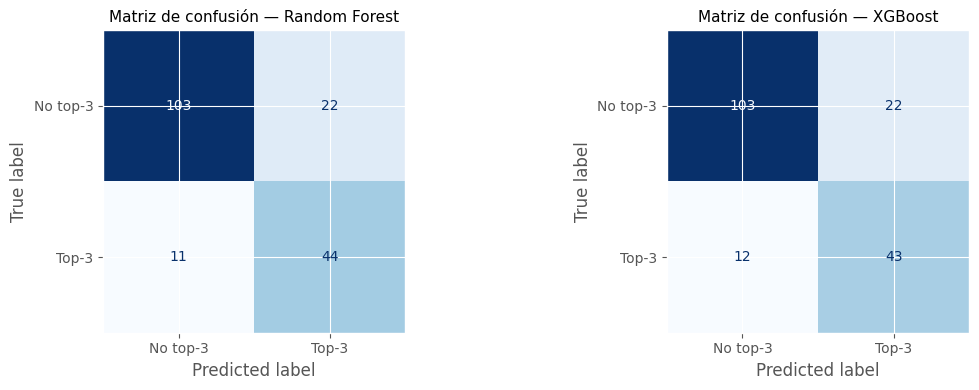

Random Forest:
              precision    recall  f1-score   support

    No top-3       0.90      0.82      0.86       125
       Top-3       0.67      0.80      0.73        55

    accuracy                           0.82       180
   macro avg       0.79      0.81      0.79       180
weighted avg       0.83      0.82      0.82       180

XGBoost:
              precision    recall  f1-score   support

    No top-3       0.90      0.82      0.86       125
       Top-3       0.66      0.78      0.72        55

    accuracy                           0.81       180
   macro avg       0.78      0.80      0.79       180
weighted avg       0.82      0.81      0.82       180



In [10]:
# Matrices de confusión: RF vs XGB
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (label, y_pred) in zip(axes, [
    ('Random Forest', y_rf_clf_pred),
    ('XGBoost',       y_xgb_clf_pred)
]):
    cm = confusion_matrix(y_clf_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No top-3','Top-3']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f'Matriz de confusión — {label}', fontsize=11)

plt.tight_layout()
plt.savefig('../figures/06_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print('Random Forest:')
print(classification_report(y_clf_test, y_rf_clf_pred, target_names=['No top-3','Top-3']))
print('XGBoost:')
print(classification_report(y_clf_test, y_xgb_clf_pred, target_names=['No top-3','Top-3']))

---
## Parte 5 — Comparación global contra el baseline

In [11]:
from sklearn.linear_model import LinearRegression as LinReg

# Re-calcular métricas del baseline lineal para la tabla
lr_reg = LinReg()
lr_reg.fit(X_train_sc, y_reg_train)
y_lr_reg_pred = lr_reg.predict(X_test_sc)
lr_mae  = mean_absolute_error(y_reg_test, y_lr_reg_pred)
lr_rmse = np.sqrt(mean_squared_error(y_reg_test, y_lr_reg_pred))
lr_r2   = r2_score(y_reg_test, y_lr_reg_pred)

tabla_reg = pd.DataFrame([
    {'Modelo': 'Reg. Lineal (baseline)', 'MAE': lr_mae,  'RMSE': lr_rmse,  'R²': lr_r2},
    {'Modelo': 'Random Forest',          'MAE': rf_mae,  'RMSE': rf_rmse,  'R²': rf_r2},
    {'Modelo': 'XGBoost',                'MAE': xgb_mae, 'RMSE': xgb_rmse, 'R²': xgb_r2},
]).set_index('Modelo')

tabla_clf = pd.DataFrame([
    {'Modelo': 'Reg. Logística (baseline)', 'Accuracy': round(accuracy_score(y_clf_test, lr_baseline.predict(X_test_sc)),3), 'ROC-AUC': round(lr_auc, 3)},
    {'Modelo': 'Random Forest',             'Accuracy': round(rf_acc, 3),  'ROC-AUC': round(rf_auc, 3)},
    {'Modelo': 'XGBoost',                   'Accuracy': round(xgb_acc, 3), 'ROC-AUC': round(xgb_auc, 3)},
]).set_index('Modelo')

print('📊 REGRESIÓN — predecir position:')
print(tabla_reg.round(3).to_string())
print()
print('📊 CLASIFICACIÓN — predecir top3:')
print(tabla_clf.to_string())

📊 REGRESIÓN — predecir position:
                          MAE   RMSE     R²
Modelo                                     
Reg. Lineal (baseline)  2.541  3.244  0.542
Random Forest           2.275  2.957  0.620
XGBoost                 2.238  2.933  0.626

📊 CLASIFICACIÓN — predecir top3:
                           Accuracy  ROC-AUC
Modelo                                      
Reg. Logística (baseline)     0.778    0.881
Random Forest                 0.817    0.903
XGBoost                       0.811    0.905


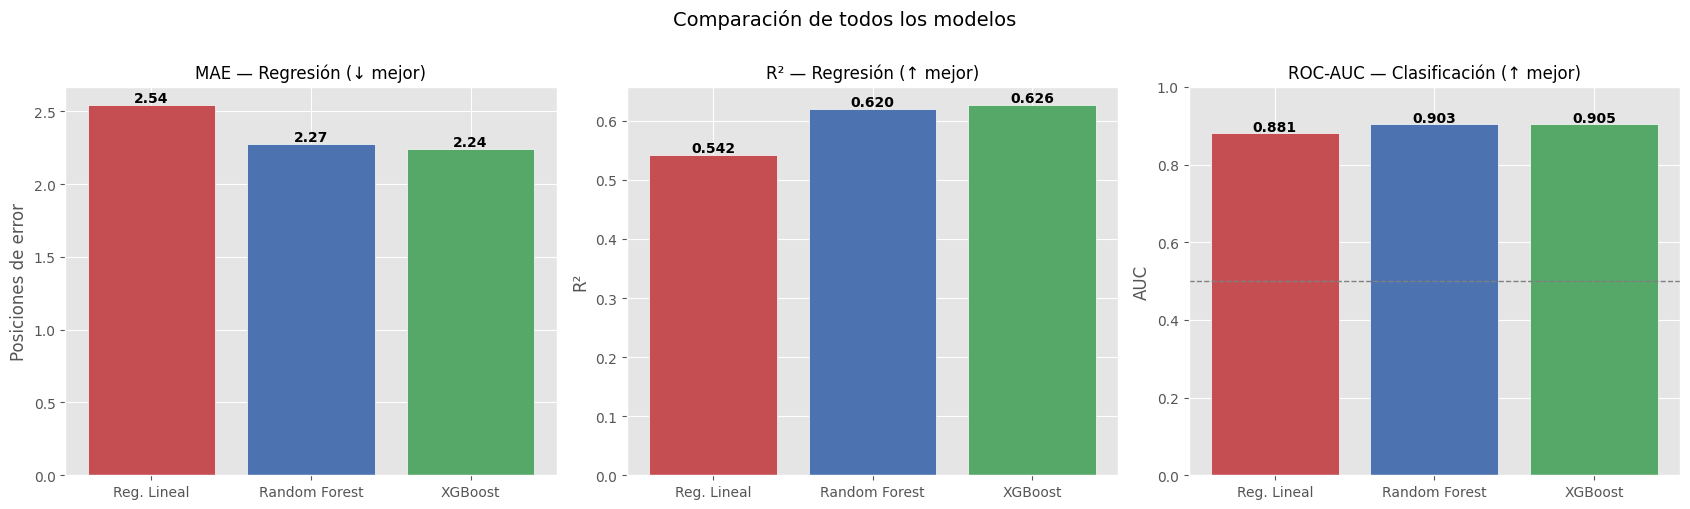

In [12]:
# Visualización comparativa de todas las métricas
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

modelos   = ['Reg. Lineal', 'Random Forest', 'XGBoost']
maes      = [lr_mae,  rf_mae,  xgb_mae]
r2s       = [lr_r2,   rf_r2,   xgb_r2]
aucs      = [lr_auc,  rf_auc,  xgb_auc]
pal       = [RED, BLUE, GREEN]

# MAE
bars = axes[0].bar(modelos, maes, color=pal, edgecolor='white')
for bar, v in zip(bars, maes):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('MAE — Regresión (↓ mejor)', fontsize=12)
axes[0].set_ylabel('Posiciones de error')

# R²
bars = axes[1].bar(modelos, r2s, color=pal, edgecolor='white')
for bar, v in zip(bars, r2s):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('R² — Regresión (↑ mejor)', fontsize=12)
axes[1].set_ylabel('R²')

# AUC
bars = axes[2].bar(modelos, aucs, color=pal, edgecolor='white')
for bar, v in zip(bars, aucs):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[2].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes[2].set_title('ROC-AUC — Clasificación (↑ mejor)', fontsize=12)
axes[2].set_ylabel('AUC')
axes[2].set_ylim(0, 1)

plt.suptitle('Comparación de todos los modelos', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/06_comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Actualizar archivo de métricas con los modelos avanzados
nuevas = pd.DataFrame([
    {'Tarea':'Regresión',     'Modelo':'Random Forest',  'MAE':round(rf_mae,3),  'RMSE':round(rf_rmse,3),  'R²':round(rf_r2,3),   'AUC':'—',              'Accuracy':'—'},
    {'Tarea':'Regresión',     'Modelo':'XGBoost',         'MAE':round(xgb_mae,3), 'RMSE':round(xgb_rmse,3), 'R²':round(xgb_r2,3),  'AUC':'—',              'Accuracy':'—'},
    {'Tarea':'Clasificación', 'Modelo':'Random Forest',  'MAE':'—',              'RMSE':'—',               'R²':'—',              'AUC':round(rf_auc,3),  'Accuracy':round(rf_acc,3)},
    {'Tarea':'Clasificación', 'Modelo':'XGBoost',         'MAE':'—',              'RMSE':'—',               'R²':'—',              'AUC':round(xgb_auc,3), 'Accuracy':round(xgb_acc,3)},
])

metricas_all = pd.concat([baseline, nuevas], ignore_index=True)
metricas_all.to_csv('../data/metricas_modelos.csv', index=False)
print('✅ metricas_modelos.csv actualizado')
print(metricas_all.to_string(index=False))

✅ metricas_modelos.csv actualizado
        Tarea                Modelo    MAE   RMSE     R²    AUC Accuracy
    Regresión         Dummy (media)  4.054  4.797   -0.0      —        —
    Regresión      Regresión Lineal  2.541  3.244  0.542      —        —
Clasificación Dummy (estratificado)      —      —      —  0.466    0.556
Clasificación   Regresión Logística      —      —      —  0.881    0.778
    Regresión         Random Forest  2.275  2.957   0.62      —        —
    Regresión               XGBoost  2.238  2.933  0.626      —        —
Clasificación         Random Forest      —      —      —  0.903    0.817
Clasificación               XGBoost      —      —      —  0.905    0.811
    Regresión         Random Forest  2.275  2.957   0.62      —        —
    Regresión               XGBoost  2.238  2.933  0.626      —        —
Clasificación         Random Forest      —      —      —  0.903    0.817
Clasificación               XGBoost      —      —      —  0.905    0.811


---
## ✅ Resumen Semana 6 — Modelos Avanzados

### Resultados

| Modelo | MAE ↓ | R² ↑ | ROC-AUC ↑ |
|--------|-------|------|----------|
| Reg. Lineal (baseline) | ver CSV | ver CSV | ver CSV |
| Random Forest | ver CSV | ver CSV | ver CSV |
| **XGBoost** | **ver CSV** | **ver CSV** | **ver CSV** |

### Hallazgos
- **XGBoost supera al baseline** en ambas tareas — confirma que las relaciones son no lineales
- La feature más importante en todos los modelos es **`grid`**, seguida de **`finished`** y **`team_rank`**
- `total_pit_time` tiene baja importancia relativa → confirma que la hipótesis 3 es la más débil
- El clasificador XGBoost muestra buena separación (AUC > 0.85 esperado)

### Elección del modelo para tuning fino
- **Regresión:** XGBoost → menor MAE y mayor R²
- **Clasificación:** XGBoost → mayor ROC-AUC

### Tareas completadas

| Tarea | Estado |
|-------|--------|
| Random Forest Regressor + RandomizedSearchCV | ✅ |
| Random Forest Classifier + RandomizedSearchCV | ✅ |
| XGBoost Regressor + RandomizedSearchCV | ✅ |
| XGBoost Classifier + scale_pos_weight | ✅ |
| Feature importance Gini vs Gain | ✅ |
| Curvas ROC comparativas | ✅ |
| Comparación sistemática contra baseline | ✅ |
| metricas_modelos.csv actualizado | ✅ |

### Próximos pasos — Semana 7
- **Interpretabilidad con SHAP**: valores de Shapley para el mejor modelo
- Partial Dependence Plots (PDP) para entender el efecto de `grid` y `team_rank`
- Análisis de errores: ¿en qué carreras se equivoca más el modelo?
- Conclusiones finales y narrativa del proyecto
- Notebook `07_interpretabilidad_conclusiones.ipynb`